# Classical Search vs. Grover's Algorithm

This notebook runs the classical linear search and a generalized Grover's
algorithm across a range of problem sizes (N = 2 up to N = 256) and plots
the results, so you can see the **O(N) vs O(√N)** scaling directly.

If you haven't already, read through
**`Grover_Algorithm_Explained.ipynb`** first. This
notebook reuses that same generalized implementation and focuses on the comparison.

**What we're measuring:** the number of *oracle queries* each approach
needs to find the one "winning" item out of N.

## Setup

In [1]:
# !pip install qiskit qiskit-aer matplotlib numpy pandas

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import random

%matplotlib inline

## 1)Classical search

Rather than just trust the textbook "N/2 on average" claim, we measure
it directly: build many random lists of size N, put a winner at a random
position, run a linear scan, and average the number of queries used
across many trials.


In [3]:
def black_box(candidate, winner):
    #The oracle: tells us whether candidate is the winning item.
    return candidate == winner


def linear_search(items, winner):
    #Scan in order, querying the black box, until the winner is found.
    #Returns the number of black-box queries used
    for i, item in enumerate(items):
        if black_box(item, winner):
            return i + 1
    raise ValueError("winner not present in items")


def benchmark_classical(n, trials=3000, seed=None):
    #Run trials: randomised linear searches over a list of size n and
    #return the empirical average query count, plus the worst case (n)
    rng = random.Random(seed)
    query_counts = []

    for _ in range(trials):
        items = list(range(n))
        rng.shuffle(items)
        winner = rng.choice(items)
        query_counts.append(linear_search(items, winner))

    avg_queries = sum(query_counts) / len(query_counts)
    return avg_queries, n  # (average, worst case)


#check
avg, worst = benchmark_classical(100, trials=5000, seed=42)
print(f"N=100: average queries = {avg:.2f}, worst case = {worst}")
print("prediction: average ~= N/2 = 50)")

N=100: average queries = 50.48, worst case = 100
prediction: average ~= N/2 = 50)


## 2) Generalized Grover's algorithm

Same implementation as notebook 1: a phase oracle and diffuser that work
for any number of qubits, and the standard formula for the optimal
number of iterations.


In [5]:
def build_oracle(n_qubits, winner):
    bits = format(winner, f"0{n_qubits}b")
    qc = QuantumCircuit(n_qubits, name="oracle")

    flip_qubits = [i for i, b in enumerate(reversed(bits)) if b == "0"]
    if flip_qubits:
        qc.x(flip_qubits)

    if n_qubits == 1:
        qc.z(0)
    else:
        qc.h(n_qubits - 1)
        qc.mcx(list(range(n_qubits -1)), n_qubits -1)
        qc.h(n_qubits - 1)

    if flip_qubits:
        qc.x(flip_qubits)

    return qc.to_gate()


def build_diffuser(n_qubits):
    qc = QuantumCircuit(n_qubits, name="diffuser")
    qc.h(range(n_qubits))
    qc.x(range(n_qubits))

    if n_qubits == 1:
        qc.z(0)
    else:
        qc.h(n_qubits - 1)
        qc.mcx(list(range(n_qubits - 1)), n_qubits -1)
        qc.h(n_qubits - 1)

    qc.x(range(n_qubits))
    qc.h(range(n_qubits))
    return qc.to_gate()


def optimal_iterations(n_qubits):
    #r ~= (pi/4)*sqrt(N) - 1/2 -- the number of iterations that
    #maximizes the probability of measuring the winning state
    n = 2 **n_qubits
    return max(1, round((math.pi / 4) * math.sqrt(n) - 0.5))


def build_grover_circuit(n_qubits, winner, iterations=None):
    if iterations is None:
        iterations = optimal_iterations(n_qubits)

    oracle = build_oracle(n_qubits, winner)
    diffuser = build_diffuser(n_qubits)

    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(range(n_qubits))
    for _ in range(iterations):
        qc.append(oracle, range(n_qubits))
        qc.append(diffuser, range(n_qubits))
    qc.measure(range(n_qubits), range(n_qubits))
    return qc


def run_grover(n_qubits, winner, iterations=None, shots=1024, seed=None):
    if iterations is None:
        iterations = optimal_iterations(n_qubits)
    backend = AerSimulator(seed_simulator=seed)
    qc = build_grover_circuit(n_qubits, winner, iterations=iterations)
    transpiled = transpile(qc, backend)
    counts = backend.run(transpiled, shots=shots).result().get_counts()
    winner_bits = format(winner, f"0{n_qubits}b")
    success_probability = counts.get(winner_bits, 0) / shots
    return counts, iterations, success_probability


# check
counts, iterations, success = run_grover(4, winner=11, shots=2048, seed=42)
print(f"N=16: iterations used = {iterations}, success probability = {success:.3f}")
print("(prediction: ~3 iterations, high success probability)")

N=16: iterations used = 3, success probability = 0.966
(prediction: ~3 iterations, high success probability)


## 3) Run across N = 2 ... 256

For each problem size N = 2ⁿ (n = 1 to 8 qubits), we:
1. Empirically measure the classical average query count (3000 random trials).
2. Compute the classical worst case (= N).
3.  Run the Grover circuit with the formula's optimal iteration count, and
   record that iteration count and the empirical success probability
   (to confirm the algorithm is actually working)

In [6]:
MAX_QUBITS = 8       # N will range from 2 up to 2**MAX_QUBITS = 256
CLASSICAL_TRIALS = 3000
SHOTS = 1024
SEED = 42

rng = random.Random(SEED)
rows = []

for n_qubits in range(1, MAX_QUBITS +1):
    n = 2** n_qubits

    classical_avg, classical_worst = benchmark_classical(n, trials=CLASSICAL_TRIALS, seed=SEED)

    winner = rng.randrange(n)
    counts, grover_iterations,grover_success = run_grover(n_qubits, winner, shots=SHOTS, seed=SEED)

    rows.append({
        "n_qubits": n_qubits,
        "N": n,
        "classical_avg_queries": classical_avg,
        "classical_worst_queries": classical_worst,
        "grover_queries": grover_iterations,
        "grover_success_probability": grover_success,
        "sqrt_N": math.sqrt(n),
    })

    print(f"N={n:4d}  classical_avg={classical_avg:7.2f}  "
          f"grover={grover_iterations:3d}  grover_success={grover_success:.3f}")

df = pd.DataFrame(rows)
df

N=   2  classical_avg=   1.51  grover=  1  grover_success=0.514
N=   4  classical_avg=   2.50  grover=  1  grover_success=1.000
N=   8  classical_avg=   4.56  grover=  2  grover_success=0.963
N=  16  classical_avg=   8.61  grover=  3  grover_success=0.973
N=  32  classical_avg=  16.73  grover=  4  grover_success=1.000
N=  64  classical_avg=  32.50  grover=  6  grover_success=0.997
N= 128  classical_avg=  64.80  grover=  8  grover_success=0.996
N= 256  classical_avg= 128.48  grover= 12  grover_success=1.000


,n_qubits,N,classical_avg_queries,classical_worst_queries,grover_queries,grover_success_probability,sqrt_N
0,1,2,1.510000,2,1,0.513672,1.414214
1,2,4,2.504333,4,1,1.000000,2.000000
2,3,8,4.558333,8,2,0.962891,2.828427
3,4,16,8.605667,16,3,0.972656,4.000000
4,5,32,16.727667,32,4,1.000000,5.656854
5,6,64,32.501000,64,6,0.997070,8.000000
6,7,128,64.804000,128,8,0.996094,11.313708
7,8,256,128.479000,256,12,1.000000,16.000000


Notice the `grover_success_probability` column stays high across every problem size the algorithmis still reliably finding the right answer with fewer queries.

## 4)Plot the scaling

We aim to visually confirm the O(√N) vs O(N) relationship


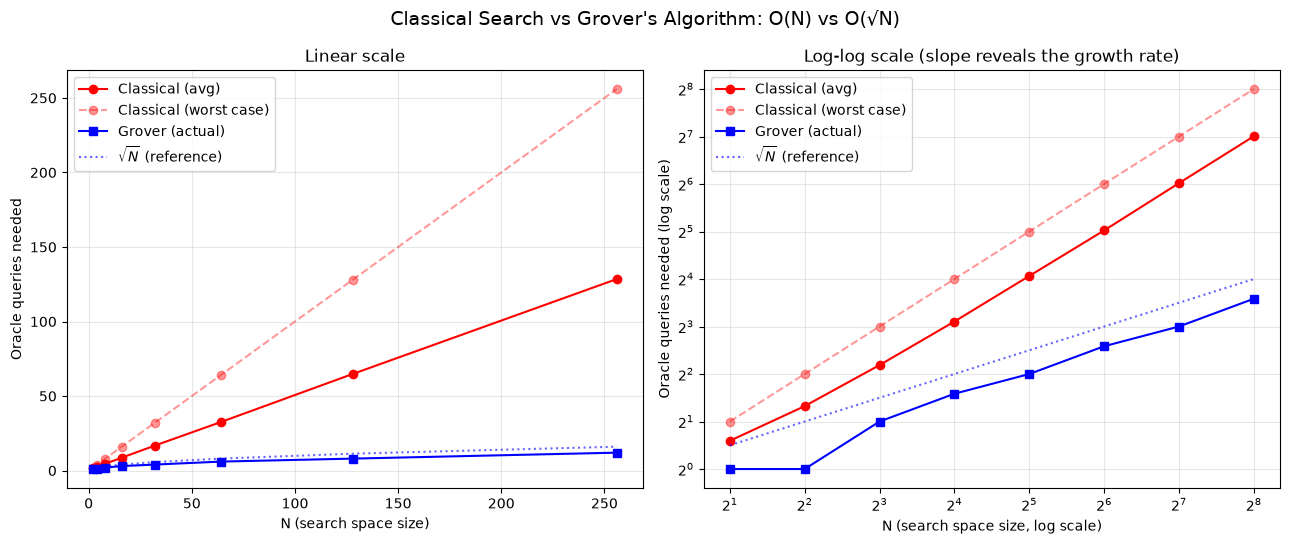

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

#Linear scale
ax = axes[0]
ax.plot(df["N"], df["classical_avg_queries"], "o-", label="Classical (avg)", color="red")
ax.plot(df["N"], df["classical_worst_queries"], "o--", label="Classical (worst case)", color="red", alpha=0.4)
ax.plot(df["N"], df["grover_queries"], "s-", label="Grover (actual)", color="blue")
ax.plot(df["N"], df["sqrt_N"], ":", label=r"$\sqrt{N}$ (reference)", color="blue", alpha=0.6)
ax.set_xlabel("N (search space size)")
ax.set_ylabel("Oracle queries needed")
ax.set_title("Linear scale")
ax.legend()
ax.grid(alpha=0.3)

#Log-log scale 
ax = axes[1]
ax.plot(df["N"], df["classical_avg_queries"], "o-", label="Classical (avg)", color="red")
ax.plot(df["N"], df["classical_worst_queries"], "o--", label="Classical (worst case)", color="red", alpha=0.4)
ax.plot(df["N"], df["grover_queries"], "s-", label="Grover (actual)", color="blue")
ax.plot(df["N"], df["sqrt_N"], ":", label=r"$\sqrt{N}$ (reference)", color="blue", alpha=0.6)
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xlabel("N (search space size, log scale)")
ax.set_ylabel("Oracle queries needed (log scale)")
ax.set_title("Log-log scale (slope reveals the growth rate)")
ax.legend()
ax.grid(alpha=0.3, which="both")

fig.suptitle("Classical Search vs Grover's Algorithm: O(N) vs O(√N)", fontsize=14)
fig.tight_layout()
plt.show()

## Summary

- Classical search needs **O(N)** oracle/black box queries on average (and in the
  worst case).
- Grover's algorithm needs only **O(√N)**, something the actual simulated quantum
  circuits achieve with high (typically >90%) success probability across
  every problem size we tested.
- The gap between the two only gets bigger as N grows, at
  N=256 classical search needs ~128 queries on average, while Grover
  needs just 12.

**Caveat worth keeping in mind:**
- This runs on a classical simulator of a quantum computer (Qiskit Aer),
  not real quantum hardware, it demonstrates the algorithmic query
  complexity but not a physical runtime comparison.

